<a href="https://colab.research.google.com/github/birukabza/A-deep-look-into-Dynamic-programming/blob/main/knapsack_implementations_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
from timeit import default_timer as timer
import matplotlib.pyplot as plt


def bruteforce(weight, profit, capacity, n):
    if n == 0:
        return 0
    if capacity == 0:
        return 0

    include = 0
    if capacity - weight[n-1] >= 0:
        include = profit[n-1] + bruteforce(
            weight, profit, capacity - weight[n-1], n-1)

    exclude = bruteforce(weight, profit, capacity, n-1)

    return max(include, exclude)


def memoized(weight, profit, capacity, n, memo=None):
    if memo is None:
        memo = {}
    if n == 0:
        return 0
    if capacity == 0:
        return 0

    if (n-1, capacity) in memo:
        return memo[(n-1, capacity)]

    include = 0
    if capacity - weight[n-1] >= 0:
        include = profit[n-1] + memoized(
            weight, profit, capacity - weight[n-1], n-1, memo
        )

    exclude = memoized(weight, profit, capacity, n-1, memo)

    memo[(n-1, capacity)] = max(include, exclude)

    return memo[(n-1, capacity)]


def iterative(weight, profit, capacity, n):
    dp = [0] * (capacity + 1)

    for i in range(n):
        for c in range(capacity, weight[i] - 1, -1):
            dp[c] = max(dp[c - weight[i]] + profit[i], dp[c])

    return dp[capacity]

In [2]:

def benchmark(func, args, runs=100):
    """Reusable function for getting the run time of a function"""
    total_time = 0
    for _ in range(runs):
        start = timer()
        func(*args)
        end = timer()
        total_time += (end - start)
    return total_time / runs


In [3]:
def visualize(x, y_values, labels, title, xlabel="Array Size", ylabel="Time (s)"):
    """
    Reusable function to plot time comparison for different algorithms.

    """
    plt.figure(figsize=(10, 6))
    markers = ["o", "s", "^", "d", "*"]
    for y, label, marker in zip(y_values, labels, markers):
        plt.plot(x, y, label=label, marker=marker)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()




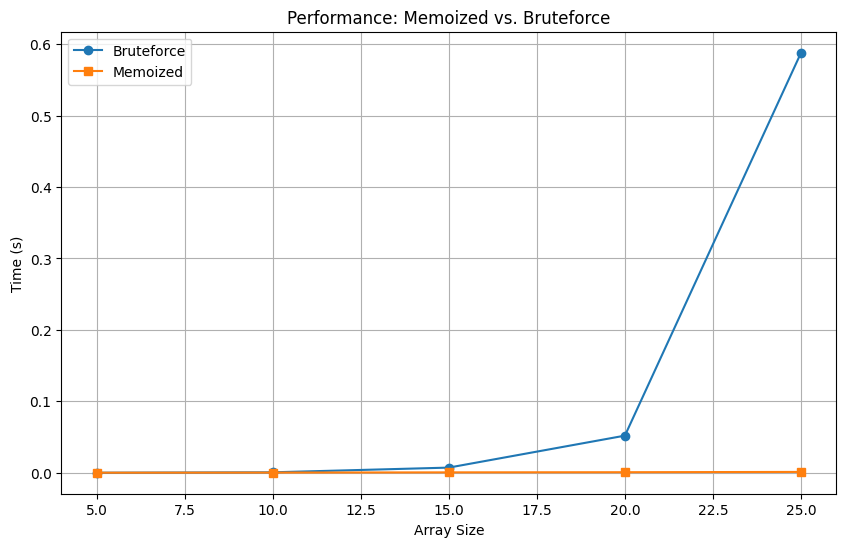

In [4]:
def test_memoized_vs_bruteforce():
    bruteforce_times = []
    memoized_times = []
    array_sizes = [5, 10, 15, 20, 25]
    capacity = 70


    for n_items in array_sizes:
        profit = [random.randint(100, 2000) for _ in range(n_items)]
        weight = [random.randint(1, 20) for _ in range(n_items)]
        # Time Bruteforce
        time_taken = benchmark(bruteforce, (weight, profit, capacity, len(weight)), 1)
        bruteforce_times.append(time_taken)

        # Time memoized 100 runs for accuracy
        time_taken = benchmark(memoized, (weight, profit, capacity, len(weight)), 100)
        memoized_times.append(time_taken)

    visualize(array_sizes, [bruteforce_times, memoized_times],
              labels=["Bruteforce", "Memoized"],
              title="Performance: Memoized vs. Bruteforce")
test_memoized_vs_bruteforce()

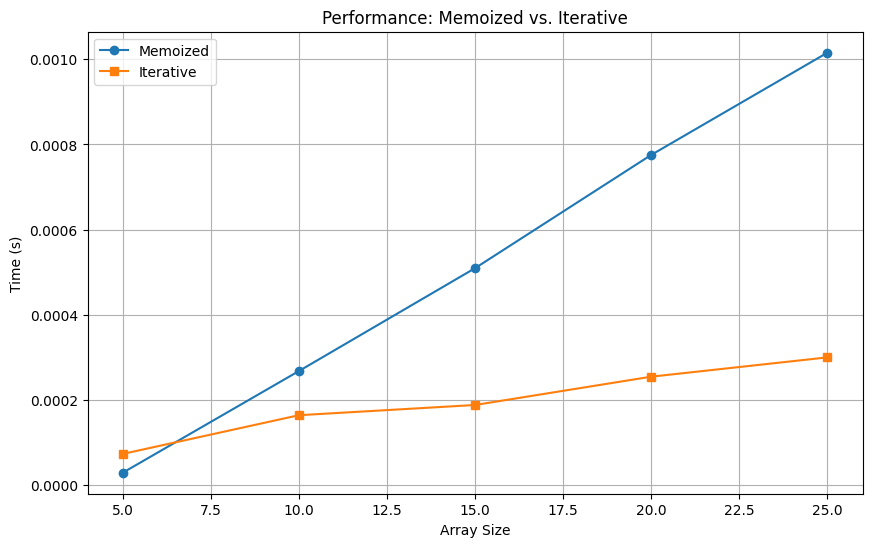

In [5]:
def test_memoized_vs_iterative():
    memoized_times = []
    iterative_times = []
    array_sizes = [5, 10, 15, 20, 25]
    capacity = 70

    for n_items in array_sizes:
        profit = [random.randint(100, 2000) for _ in range(n_items)]
        weight = [random.randint(1, 20) for _ in range(n_items)]

        memoized_times.append(
            benchmark(memoized,  (weight, profit, capacity, len(weight)), runs=100)
        )
        iterative_times.append(
            benchmark(iterative, (weight, profit, capacity, len(weight)), runs=100)
        )

    visualize(
        x=array_sizes,
        y_values=[memoized_times, iterative_times],
        labels=["Memoized", "Iterative"],
        title="Performance: Memoized vs. Iterative"
    )

test_memoized_vs_iterative()


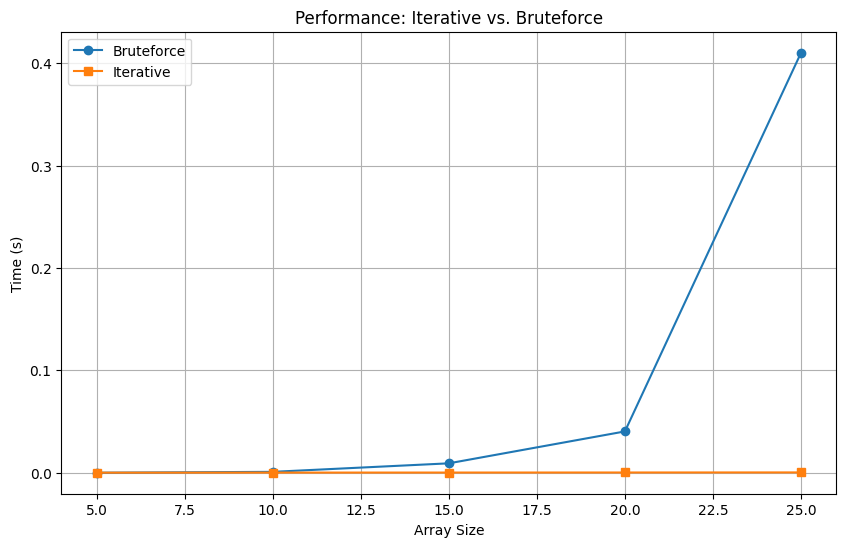

In [6]:
def test_iterative_vs_bruteforce():
    bruteforce_times = []
    iterative_times  = []
    array_sizes = [5, 10, 15, 20, 25]
    capacity    = 70

    for n_items in array_sizes:
        profit = [random.randint(100, 2000) for _ in range(n_items)]
        weight = [random.randint(1, 20)   for _ in range(n_items)]

        bruteforce_times.append(
            benchmark(bruteforce, (weight, profit, capacity, len(weight)), runs=1)
        )

        iterative_times.append(
            benchmark(iterative,  (weight, profit, capacity, len(weight)), runs=100)
        )

    visualize(
        x=array_sizes,
        y_values=[bruteforce_times, iterative_times],
        labels=["Bruteforce", "Iterative"],
        title="Performance: Iterative vs. Bruteforce"
    )

test_iterative_vs_bruteforce()


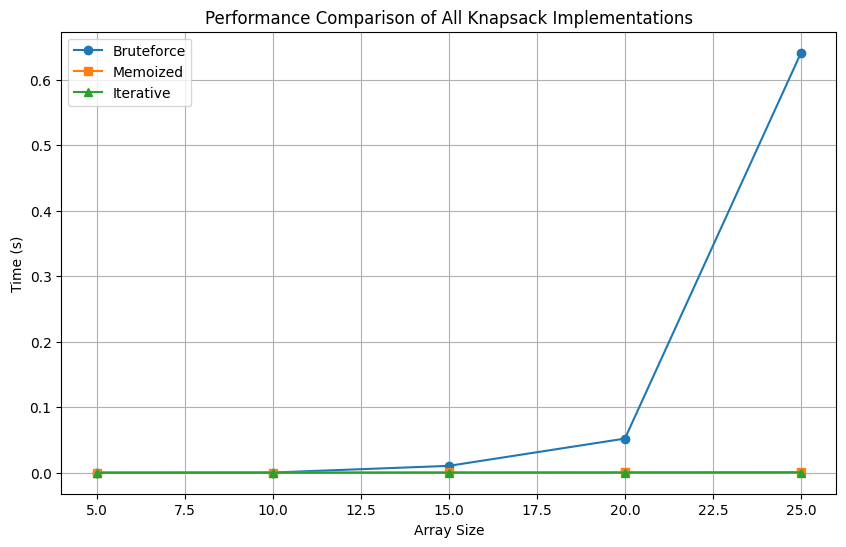

In [7]:
def test_all_three_methods():
    bruteforce_times = []
    memoized_times  = []
    iterative_times = []
    array_sizes = [5, 10, 15, 20, 25]
    capacity    = 70

    for n_items in array_sizes:
        profit = [random.randint(100, 2000) for _ in range(n_items)]
        weight = [random.randint(1, 20)   for _ in range(n_items)]

        bruteforce_times.append(
            benchmark(bruteforce, (weight, profit, capacity, len(weight)), runs=1)
        )

        memoized_times.append(
            benchmark(memoized,  (weight, profit, capacity, len(weight)), runs=100)
        )

        iterative_times.append(
            benchmark(iterative, (weight, profit, capacity, len(weight)),  runs=100)
        )

    visualize(
        x=array_sizes,
        y_values=[bruteforce_times, memoized_times, iterative_times],
        labels=["Bruteforce", "Memoized", "Iterative"],
        title="Performance Comparison of All Knapsack Implementations"
    )

test_all_three_methods()


In [ ]:
def compare_methods_over_range(min_items=5, max_items=32, capacity=70, runs=100):
    bruteforce_total, memoized_total, iterative_total = 0, 0, 0
    num_tests = 0

    for n_items in range(min_items, max_items + 1):
        profit = [random.randint(100, 2000) for _ in range(n_items)]
        weight = [random.randint(1, 20) for _ in range(n_items)]

        time_brute = benchmark(bruteforce, (weight, profit, capacity, len(weight)), 1)


        time_memo = benchmark(memoized, (weight, profit, capacity, len(weight)), runs)
        time_iter = benchmark(iterative, (weight, profit, capacity, len(weight)), runs)

        bruteforce_total += time_brute
        memoized_total += time_memo
        iterative_total += time_iter
        num_tests += 1

    print("\n=== AVERAGE TIMES OVER RANGE ===")
    print(f"Bruteforce Avg: {bruteforce_total / num_tests:.6f} s")
    print(f"Memoized Avg  : {memoized_total / num_tests:.6f} s")
    print(f"Iterative Avg : {iterative_total / num_tests:.6f} s")

    print("\n=== SPEEDUP RATIOS ===")
    print(f"Memoized is {(bruteforce_total / memoized_total):.2f}x faster than Bruteforce")
    print(f"Iterative is {(memoized_total / iterative_total):.2f}x faster than Memoized")
    print(f"Iterative is {(bruteforce_total / iterative_total):.2f}x faster than Bruteforce")

compare_methods_over_range()


=== AVERAGE TIMES OVER RANGE ===
Bruteforce Avg: 0.716992 s
Memoized Avg  : 0.000958 s
Iterative Avg : 0.000315 s

=== SPEEDUP RATIOS ===
Memoized is 748.57x faster than Bruteforce
Iterative is 3.04x faster than Memoized
Iterative is 2274.82x faster than Bruteforce
